In [9]:
import pandas as pd
from pathlib import Path

CSV_PATH = Path(r"C:\Users\Nasiba\Documents\1 Master Data Science\Master Thesis\VS Code New\master_thesis-rag\main\evaluation\graphrag\out\llm_judge_results.csv")
df_old = pd.read_csv(CSV_PATH)

CSV_PATH_HYB = Path(r"C:\Users\Nasiba\Documents\1 Master Data Science\Master Thesis\VS Code New\master_thesis-rag\main\evaluation\graphrag\out\llm_judge_results_hybrid.csv")
df_hybrid = pd.read_csv(CSV_PATH_HYB)

CSV_PATH_NEW = Path(r"C:\Users\Nasiba\Documents\1 Master Data Science\Master Thesis\VS Code New\master_thesis-rag\main\evaluation\graphrag\out\llm_judge_results_answers_log_new_dataset_fixed.csv")
df_new = pd.read_csv(CSV_PATH_NEW)




df = pd.concat([df_old, df_hybrid, df_new], ignore_index=True)




In [4]:


cols = ["script", "faithfulness_score", "answer_relevance_score", "completeness_score"]
df = df[cols].copy()


summary = (
    df.groupby("script", as_index=False)
      .agg(
          Faith=("faithfulness_score", "mean"),
          Ans_Rel=("answer_relevance_score", "mean"),
          Cont_Rel=("completeness_score", "mean"),
          N=("script", "size"),
      )
)


summary_no_n = summary.drop(columns=["N"])


summary_no_n = summary_no_n.set_index("script").round(2)

print(summary_no_n.to_string())


                                           Faith  Ans_Rel  Cont_Rel
script                                                             
ENSEMBLE_BM25_VECTOR_PG_RERANK              0.10     0.75      0.54
KG_PGRetriever_LlamaIndex                   0.16     0.73      0.44
LLMGraphTransformer_HybridCypherRetriever   0.15     0.73      0.52
LLMGraphTransformer_VectorCypherRetriever   0.11     0.73      0.51
ONLY_RAG_Advanced                           0.21     0.66      0.09
ONLY_RAG_Sparse_Advanced                    0.16     0.71      0.54
SimpleKGPipeline_HybridCypherRetriever      0.15     0.74      0.48
SimpleKGPipeline_VectorCypherRetriever      0.13     0.73      0.48


In [20]:


cols = ["query_type", "faithfulness_score", "answer_relevance_score", "completeness_score"]
df = df[cols].copy()


summary = (
    df.groupby("query_type", as_index=False)
      .agg(
          Faith=("faithfulness_score", "mean"),
          Ans_Rel=("answer_relevance_score", "mean"),
          Cont_Rel=("completeness_score", "mean"),
          N=("query_type", "size"),
      )
)


summary_no_n = summary.drop(columns=["N"])


summary_no_n = summary_no_n.set_index("query_type").round(2)

print(summary_no_n.to_string())


                Faith  Ans_Rel  Cont_Rel
query_type                              
disambiguation   0.16     0.72      0.49
factual          0.14     0.80      0.51
multi_hop        0.13     0.70      0.48
reasoning        0.16     0.69      0.44
relational       0.13     0.72      0.46
summary          0.17     0.72      0.42


In [6]:
df["TP"] = (df["correctness_category"] == "TP").astype(int)
df["FP"] = (df["correctness_category"] == "FP").astype(int)
df["FN"] = (df["correctness_category"] == "FN").astype(int)
summary = (
    df.groupby("script", as_index=False)
      .agg(
          TP=("TP", "sum"),
          FP=("FP", "sum"),
          FN=("FN", "sum"),
      )
)
summary["Precision"] = summary["TP"] / (summary["TP"] + summary["FP"])
summary["Recall"]    = summary["TP"] / (summary["TP"] + summary["FN"])
summary["F1"]        = (
    2 * summary["Precision"] * summary["Recall"]
    / (summary["Precision"] + summary["Recall"])
)
summary_display = (
    summary
    .set_index("script")[["Precision", "Recall", "F1"]]
    .round(2)
)

print(summary_display.to_string())


                                           Precision  Recall    F1
script                                                            
ENSEMBLE_BM25_VECTOR_PG_RERANK                  0.58    0.95  0.72
KG_PGRetriever_LlamaIndex                       0.53    0.82  0.64
LLMGraphTransformer_HybridCypherRetriever       0.54    0.92  0.68
LLMGraphTransformer_VectorCypherRetriever       0.52    0.89  0.66
ONLY_RAG_Advanced                               0.21    0.08  0.12
ONLY_RAG_Sparse_Advanced                        0.60    0.94  0.73
SimpleKGPipeline_HybridCypherRetriever          0.51    0.91  0.65
SimpleKGPipeline_VectorCypherRetriever          0.51    0.89  0.65


In [ ]:
counts = (
    df.groupby(["script", "correctness_category"])
      .size()
      .unstack(fill_value=0)
)
counts = counts.reindex(columns=["TP", "FP", "FN"], fill_value=0)
print(counts)




KeyError: 'correctness_category'

In [22]:
df_new["TP"] = (df_new["correctness_category"] == "TP").astype(int)
df_new["FP"] = (df_new["correctness_category"] == "FP").astype(int)
df_new["FN"] = (df_new["correctness_category"] == "FN").astype(int)
summary = (
    df_new.groupby("script", as_index=False)
      .agg(
          TP=("TP", "sum"),
          FP=("FP", "sum"),
          FN=("FN", "sum"),
      )
)
summary["Precision"] = summary["TP"] / (summary["TP"] + summary["FP"])
summary["Recall"]    = summary["TP"] / (summary["TP"] + summary["FN"])
summary["F1"]        = (
    2 * summary["Precision"] * summary["Recall"]
    / (summary["Precision"] + summary["Recall"])
)
summary_display = (
    summary
    .set_index("script")[["Precision", "Recall", "F1"]]
    .round(2)
)

print(summary_display.to_string())


                                           Precision  Recall    F1
script                                                            
ENSEMBLE_BM25_VECTOR_PG_RERANK                  0.30    1.00  0.46
KG_PGRetriever_LlamaIndex                       0.33    0.75  0.46
LLMGraphTransformer_HybridCypherRetriever       0.30    1.00  0.46
LLMGraphTransformer_VectorCypherRetriever       0.20    1.00  0.33
ONLY_RAG_Advanced                               0.00    0.00   NaN
ONLY_RAG_HYBRID_Advanced                        0.30    1.00  0.46
ONLY_RAG_Sparse_Advanced                        0.20    1.00  0.33
SimpleKGPipeline_HybridCypherRetriever          0.20    1.00  0.33
SimpleKGPipeline_VectorCypherRetriever          0.20    1.00  0.33


In [10]:
counts = (
    df_new.groupby(["script", "correctness_category"])
      .size()
      .unstack(fill_value=0)
)
counts = counts.reindex(columns=["TP", "FP", "FN"], fill_value=0)
print(counts)




correctness_category                       TP  FP  FN
script                                               
ENSEMBLE_BM25_VECTOR_PG_RERANK              3   7   0
GLOBAL_COMMUNITY_SUMMARY_RETRIEVER_LVL1     4   5   1
KG_PGRetriever_LlamaIndex                   3   6   1
LLMGraphTransformer_HybridCypherRetriever   3   7   0
LLMGraphTransformer_VectorCypherRetriever   2   8   0
ONLY_RAG_Advanced                           0   3   7
ONLY_RAG_HYBRID_Advanced                    3   7   0
ONLY_RAG_Sparse_Advanced                    2   8   0
SIMPLEKG_HYBRID_RERANK_FIXED                2   8   0
SimpleKGPipeline_HybridCypherRetriever      2   8   0
SimpleKGPipeline_VectorCypherRetriever      2   8   0


In [11]:


cols = ["script", "faithfulness_score", "answer_relevance_score", "completeness_score"]
df_new = df_new[cols].copy()


summary = (
    df_new.groupby("script", as_index=False)
      .agg(
          Faith=("faithfulness_score", "mean"),
          Ans_Rel=("answer_relevance_score", "mean"),
          Cont_Rel=("completeness_score", "mean"),
          N=("script", "size"),
      )
)


summary_no_n = summary.drop(columns=["N"])


summary_no_n = summary_no_n.set_index("script").round(2)

print(summary_no_n.to_string())


                                           Faith  Ans_Rel  Cont_Rel
script                                                             
ENSEMBLE_BM25_VECTOR_PG_RERANK              0.44     0.72      0.29
GLOBAL_COMMUNITY_SUMMARY_RETRIEVER_LVL1     0.10     0.71      0.33
KG_PGRetriever_LlamaIndex                   0.07     0.75      0.21
LLMGraphTransformer_HybridCypherRetriever   0.01     0.64      0.25
LLMGraphTransformer_VectorCypherRetriever   0.00     0.67      0.26
ONLY_RAG_Advanced                           0.39     0.66      0.04
ONLY_RAG_HYBRID_Advanced                    0.00     0.63      0.42
ONLY_RAG_Sparse_Advanced                    0.18     0.66      0.31
SIMPLEKG_HYBRID_RERANK_FIXED                0.25     0.64      0.41
SimpleKGPipeline_HybridCypherRetriever      0.03     0.64      0.30
SimpleKGPipeline_VectorCypherRetriever      0.01     0.66      0.28


In [43]:
df[(df["correctness_category"]!="TP")&(df["script"]=="KG_PGRetriever_LlamaIndex")]  # Replace with actual script name

,script,question_id,query_type,answer_relevance_score,completeness_score,correctness_category,faithfulness_score,metrics_json,TP,FP,FN
183,KG_PGRetriever_LlamaIndex,4,relational,0.864433,0.00,FP,0.0,"{""answer_relevance"": {""score"": 0.8644325534502...",0,1,0
184,KG_PGRetriever_LlamaIndex,5,summary,0.741118,0.20,FN,0.0,"{""answer_relevance"": {""score"": 0.7411180337270...",0,0,1
186,KG_PGRetriever_LlamaIndex,7,reasoning,0.676779,0.00,FP,0.0,"{""answer_relevance"": {""score"": 0.6767787535985...",0,1,0
190,KG_PGRetriever_LlamaIndex,11,factual,0.895565,0.00,FP,0.0,"{""answer_relevance"": {""score"": 0.8955645163853...",0,1,0
191,KG_PGRetriever_LlamaIndex,12,relational,0.731110,0.25,FP,0.0,"{""answer_relevance"": {""score"": 0.7311097482840...",0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
348,KG_PGRetriever_LlamaIndex,169,factual,0.764430,0.50,FP,0.0,"{""answer_relevance"": {""score"": 0.7644304434458...",0,1,0
349,KG_PGRetriever_LlamaIndex,170,relational,0.846680,0.00,FP,0.0,"{""answer_relevance"": {""score"": 0.8466799855232...",0,1,0
352,KG_PGRetriever_LlamaIndex,173,reasoning,0.605961,0.75,FP,0.0,"{""answer_relevance"": {""score"": 0.6059605280558...",0,1,0
353,KG_PGRetriever_LlamaIndex,174,multi_hop,0.863423,1.00,FP,0.0,"{""answer_relevance"": {""score"": 0.8634234269460...",0,1,0


In [54]:
df[(df["question_id"]==4)]  # Replace with actual script name

,script,question_id,query_type,answer_relevance_score,completeness_score,correctness_category,faithfulness_score,metrics_json,TP,FP,FN
3,ONLY_RAG_Advanced,4,relational,0.777986,0.00,FN,1.0,"{""answer_relevance"": {""score"": 0.7779857714970...",0,0,1
183,KG_PGRetriever_LlamaIndex,4,relational,0.864433,0.00,FP,0.0,"{""answer_relevance"": {""score"": 0.8644325534502...",0,1,0
362,LLMGraphTransformer_VectorCypherRetriever,4,relational,0.824271,0.00,FP,0.0,"{""answer_relevance"": {""score"": 0.8242705464363...",0,1,0
541,SimpleKGPipeline_VectorCypherRetriever,4,relational,0.778057,0.75,TP,0.0,"{""answer_relevance"": {""score"": 0.7780565222104...",1,0,0
720,ONLY_RAG_Sparse_Advanced,4,relational,0.719428,0.75,TP,0.0,"{""answer_relevance"": {""score"": 0.7194281617800...",1,0,0


In [42]:
df[(df["question_id"]==167)&(df["script"]!="ONLY_RAG_Advanced")]  # Replace with actual script name

,script,question_id,query_type,answer_relevance_score,completeness_score,correctness_category,faithfulness_score,metrics_json,TP,FP,FN
346,KG_PGRetriever_LlamaIndex,167,multi_hop,0.653798,0.333333,FP,0.0,"{""answer_relevance"": {""score"": 0.6537979046503...",0,1,0
525,LLMGraphTransformer_VectorCypherRetriever,167,multi_hop,0.611447,0.666667,FP,0.0,"{""answer_relevance"": {""score"": 0.6114471654097...",0,1,0
704,SimpleKGPipeline_VectorCypherRetriever,167,multi_hop,0.639583,0.750000,TP,0.0,"{""answer_relevance"": {""score"": 0.6395830611387...",1,0,0
883,ONLY_RAG_Sparse_Advanced,167,multi_hop,0.635931,0.750000,FP,1.0,"{""answer_relevance"": {""score"": 0.6359313527743...",0,1,0


In [39]:
df[(df["correctness_category"]!="TP")&(df["script"]=="ONLY_RAG_Sparse_Advanced")]  # Replace with actual script name

,script,question_id,query_type,answer_relevance_score,completeness_score,correctness_category,faithfulness_score,metrics_json,TP,FP,FN
723,ONLY_RAG_Sparse_Advanced,7,reasoning,0.821351,0.00,FN,1.000000,"{""answer_relevance"": {""score"": 0.8213508923848...",0,0,1
727,ONLY_RAG_Sparse_Advanced,11,factual,0.709968,0.00,FP,0.000000,"{""answer_relevance"": {""score"": 0.7099679509798...",0,1,0
732,ONLY_RAG_Sparse_Advanced,16,reasoning,0.749801,0.00,FP,0.000000,"{""answer_relevance"": {""score"": 0.7498012979825...",0,1,0
735,ONLY_RAG_Sparse_Advanced,19,relational,0.793264,0.00,FP,0.000000,"{""answer_relevance"": {""score"": 0.7932639916737...",0,1,0
736,ONLY_RAG_Sparse_Advanced,20,summary,0.803038,1.00,FP,0.000000,"{""answer_relevance"": {""score"": 0.8030377427736...",0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
883,ONLY_RAG_Sparse_Advanced,167,multi_hop,0.635931,0.75,FP,1.000000,"{""answer_relevance"": {""score"": 0.6359313527743...",0,1,0
886,ONLY_RAG_Sparse_Advanced,170,relational,0.823130,0.50,FP,0.857143,"{""answer_relevance"": {""score"": 0.8231296539306...",0,1,0
889,ONLY_RAG_Sparse_Advanced,173,reasoning,0.703463,0.75,FP,0.000000,"{""answer_relevance"": {""score"": 0.7034629185994...",0,1,0
890,ONLY_RAG_Sparse_Advanced,174,multi_hop,0.768623,0.40,FP,0.000000,"{""answer_relevance"": {""score"": 0.7686228553454...",0,1,0


In [37]:
df[(df["correctness_category"]!="TP")&(df["script"]=="ENSEMBLE_BM25_VECTOR_PG_RERANK")]  # Replace with actual script name

,script,question_id,query_type,answer_relevance_score,completeness_score,correctness_category,faithfulness_score,metrics_json,TP,FP,FN
1171,ENSEMBLE_BM25_VECTOR_PG_RERANK,3,relational,0.820875,0.500000,FP,0.000000,"{""answer_relevance"": {""score"": 0.8208752075831...",0,1,0
1196,ENSEMBLE_BM25_VECTOR_PG_RERANK,5,summary,0.682407,0.666667,FP,0.000000,"{""answer_relevance"": {""score"": 0.6824072798093...",0,1,0
1232,ENSEMBLE_BM25_VECTOR_PG_RERANK,9,disambiguation,0.681363,0.750000,FP,0.142857,"{""answer_relevance"": {""score"": 0.6813626488049...",0,1,0
1262,ENSEMBLE_BM25_VECTOR_PG_RERANK,12,relational,0.911853,0.333333,FP,0.000000,"{""answer_relevance"": {""score"": 0.9118525584538...",0,1,0
1276,ENSEMBLE_BM25_VECTOR_PG_RERANK,20,summary,0.791043,0.333333,FP,0.000000,"{""answer_relevance"": {""score"": 0.7910432219505...",0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
1426,ENSEMBLE_BM25_VECTOR_PG_RERANK,170,relational,0.813271,0.500000,FP,0.000000,"{""answer_relevance"": {""score"": 0.8132709066073...",0,1,0
1429,ENSEMBLE_BM25_VECTOR_PG_RERANK,173,reasoning,0.746451,0.500000,FP,0.000000,"{""answer_relevance"": {""score"": 0.7464506427447...",0,1,0
1430,ENSEMBLE_BM25_VECTOR_PG_RERANK,174,multi_hop,0.861492,0.600000,FP,0.000000,"{""answer_relevance"": {""score"": 0.8614920179049...",0,1,0
1432,ENSEMBLE_BM25_VECTOR_PG_RERANK,176,disambiguation,0.756650,0.333333,FP,0.000000,"{""answer_relevance"": {""score"": 0.7566500902175...",0,1,0


In [17]:
from pathlib import Path
import pandas as pd
CSV_PATH_NEW = Path(r"C:\Users\Nasiba\Documents\1 Master Data Science\Master Thesis\VS Code New\master_thesis-rag\main\evaluation\graphrag\out\llm_judge_results_answers_log_new copy 2.csv")

df_new = pd.read_csv(CSV_PATH_NEW)

In [4]:
counts = (
    df_new.groupby(["script", "correctness_category"])
      .size()
      .unstack(fill_value=0)
)
counts = counts.reindex(columns=["TP", "FP", "FN"], fill_value=0)
print(counts)




correctness_category                        TP  FP  FN
script                                                
ENSEMBLE_BM25_VECTOR_PG_RERANK               3   7   0
HYBRID_LLmaIndex_RERANK_NEW                  2   8   0
KG_PGRetriever_LlamaIndex                    3   6   1
LLMGraphTransformer_HybridCypherRetriever    3   7   0
LLMGraphTransformer_MANUAL_HYBRID_RERANKED   2   3   5
LLMGraphTransformer_VectorCypherRetriever    2   8   0
ONLY_RAG_Advanced                            0   3   7
ONLY_RAG_HYBRID_Advanced                     3   7   0
ONLY_RAG_Sparse_Advanced                     2   8   0
SimpleKGPipeline_HybridCypherRetriever       2   8   0
SimpleKGPipeline_VectorCypherRetriever       2   8   0


In [2]:


cols = ["script", "faithfulness_score", "answer_relevance_score", "completeness_score"]
df_new = df_new[cols].copy()


summary = (
    df_new.groupby("script", as_index=False)
      .agg(
          Faith=("faithfulness_score", "mean"),
          Ans_Rel=("answer_relevance_score", "mean"),
          Cont_Rel=("completeness_score", "mean"),
          N=("script", "size"),
      )
)


summary_no_n = summary.drop(columns=["N"])


summary_no_n = summary_no_n.set_index("script").round(2)

print(summary_no_n.to_string())


                                            Faith  Ans_Rel  Cont_Rel
script                                                              
ENSEMBLE_BM25_VECTOR_PG_RERANK               0.44     0.72      0.29
HYBRID_LLmaIndex_RERANK_NEW                  0.42     0.74      0.32
KG_PGRetriever_LlamaIndex                    0.07     0.75      0.21
LLMGraphTransformer_HybridCypherRetriever    0.01     0.64      0.25
LLMGraphTransformer_MANUAL_HYBRID_RERANKED   0.78     0.73      0.26
LLMGraphTransformer_VectorCypherRetriever    0.00     0.67      0.26
ONLY_RAG_Advanced                            0.39     0.66      0.04
ONLY_RAG_HYBRID_Advanced                     0.00     0.63      0.42
ONLY_RAG_Sparse_Advanced                     0.18     0.66      0.31
SimpleKGPipeline_HybridCypherRetriever       0.03     0.64      0.30
SimpleKGPipeline_VectorCypherRetriever       0.01     0.66      0.28


In [46]:
import pandas as pd
from pathlib import Path
# Pfad ggf. anpassen
CSV_PATH_answers = Path(
    r"C:\Users\Nasiba\Documents\1 Master Data Science\Master Thesis\VS Code New\master_thesis-rag\main\evaluation\answers_log_fixed.csv"
)
CSV_PATH_answers2 = Path(
    r"C:\Users\Nasiba\Documents\1 Master Data Science\Master Thesis\VS Code New\master_thesis-rag\main\evaluation\answers_log_fixed_sparse.csv"
)
# Größe prüfen
import csv
from typing import Optional
df_answers1= pd.read_csv(CSV_PATH_answers)
df_answers2= pd.read_csv(CSV_PATH_answers2)

In [47]:
import pandas as pd

df_answers = pd.concat([df_answers1, df_answers2], ignore_index=True)


In [48]:
df_answers.loc[
    df_answers["question_id"] == 4,
    ["script", "question", "answer", "gold_answer"]
]


,script,question,answer,gold_answer
3,ONLY_RAG_Advanced,Which components on the Nicla Voice connect to...,The documentation snippet does not contain inf...,The BMI270 6-axis IMU and the BMM150 magnetome...
183,KG_PGRetriever_LlamaIndex,Which components on the Nicla Voice connect to...,The components on the Nicla Voice that connect...,The BMI270 6-axis IMU and the BMM150 magnetome...
362,LLMGraphTransformer_VectorCypherRetriever,Which components on the Nicla Voice connect to...,The components on the Nicla Voice that connect...,The BMI270 6-axis IMU and the BMM150 magnetome...
541,SimpleKGPipeline_VectorCypherRetriever,Which components on the Nicla Voice connect to...,The components on the Nicla Voice that connect...,The BMI270 6-axis IMU and the BMM150 magnetome...
720,ONLY_RAG_Sparse_Advanced,Which components on the Nicla Voice connect to...,The components connected to the Syntiant® NDP1...,The BMI270 6-axis IMU and the BMM150 magnetome...


In [ ]:
row = df_answers[df_answers["question_id"] == 4].iloc[0]
#4,5,7,11,12

print("SCRIPT:\n", row["script"])
print("\nQUESTION:\n", row["question"])
print("\nANSWER:\n", row["answer"])
print("\nGOLD ANSWER:\n", row["gold_answer"])


SCRIPT:
 ONLY_RAG_Advanced

QUESTION:
 Which components on the Nicla Voice connect to the NDP120 via SPI?

ANSWER:
 The documentation snippet does not contain information about which components on the Nicla Voice connect to the NDP120 via SPI.

GOLD ANSWER:
 The BMI270 6-axis IMU and the BMM150 magnetometer connect to the NDP120 via SPI.


In [64]:
row = df_answers[df_answers["question_id"] == 174].iloc[1]
#169,170, 173, 174
print("SCRIPT:\n", row["script"])
print("\nQUESTION:\n", row["question"])
print("\nANSWER:\n", row["answer"])
print("\nGOLD ANSWER:\n", row["gold_answer"])


SCRIPT:
 KG_PGRetriever_LlamaIndex

QUESTION:
 I want to read humidity data from an Arduino Cloud Thing inside Node-RED, but nothing appears. What steps must work together for this to function correctly?

ANSWER:
 ('To read humidity data from an Arduino Cloud Thing inside Node-RED, ensure the following steps are correctly implemented:nn1. **Install Node-RED**: Make sure Node-RED is installed and running on your system.nn2. **Add Arduino Cloud Nodes**: Use the palette manager in Node-RED to install the Arduino Cloud nodes. This can be done by clicking on the menu in the header bar, selecting "Manage palette," and then going to the "install" tab to search for and install the Arduino Cloud nodes.nn3. **Create a Thing**: Set up a Thing in the Arduino Cloud that is configured to read humidity values. This Thing should be linked to a humidity sensor, such as the DHT11 or HS3003.nn4. **Add Property Out Node**: In Node-RED, add the Arduino Cloud "property out" node from the palette menu. Doubl

In [51]:
row = df_answers[df_answers["question_id"] == 4].iloc[2]

print("SCRIPT:\n", row["script"])
print("\nQUESTION:\n", row["question"])
print("\nANSWER:\n", row["answer"])
print("\nGOLD ANSWER:\n", row["gold_answer"])


SCRIPT:
 LLMGraphTransformer_VectorCypherRetriever

QUESTION:
 Which components on the Nicla Voice connect to the NDP120 via SPI?

ANSWER:
 The components on the Nicla Voice that connect to the NDP120 via SPI are the data logging 16MB flash (U7) and the ANNA-B112 module, which acts as the SPI host for the NDP120.

GOLD ANSWER:
 The BMI270 6-axis IMU and the BMM150 magnetometer connect to the NDP120 via SPI.


In [52]:
row = df_answers[df_answers["question_id"] == 4].iloc[3]

print("SCRIPT:\n", row["script"])
print("\nQUESTION:\n", row["question"])
print("\nANSWER:\n", row["answer"])
print("\nGOLD ANSWER:\n", row["gold_answer"])


SCRIPT:
 SimpleKGPipeline_VectorCypherRetriever

QUESTION:
 Which components on the Nicla Voice connect to the NDP120 via SPI?

ANSWER:
 The components on the Nicla Voice that connect to the NDP120 via SPI are the BMM150 3-axis magnetometer and the BMI270 6-axis IMU. The NDP120 acts as the SPI host for these components.

GOLD ANSWER:
 The BMI270 6-axis IMU and the BMM150 magnetometer connect to the NDP120 via SPI.


In [53]:
row = df_answers[df_answers["question_id"] == 4].iloc[4]

print("SCRIPT:\n", row["script"])
print("\nQUESTION:\n", row["question"])
print("\nANSWER:\n", row["answer"])
print("\nGOLD ANSWER:\n", row["gold_answer"])


SCRIPT:
 ONLY_RAG_Sparse_Advanced

QUESTION:
 Which components on the Nicla Voice connect to the NDP120 via SPI?

ANSWER:
 The components connected to the Syntiant® NDP120 (U3) via SPI on the Nicla Voice are the BMM150 3-axis magnetometer (U4) and the BMI270 6-axis IMU (U15). The NDP120 acts as the SPI host for both these sensors. The documentation does not mention any other components connected to the NDP120 via SPI.

GOLD ANSWER:
 The BMI270 6-axis IMU and the BMM150 magnetometer connect to the NDP120 via SPI.


In [9]:
df[df["answer_relevance_score"]<0.5]

,script,question_id,query_type,answer_relevance_score,completeness_score,correctness_category,faithfulness_score,metrics_json
7,ONLY_RAG_Advanced,8,relational,0.487948,0.00,FP,0.000000,"{""answer_relevance"": {""score"": 0.4879477322101..."
29,ONLY_RAG_Advanced,30,relational,0.498880,1.00,TP,0.000000,"{""answer_relevance"": {""score"": 0.4988803366820..."
38,ONLY_RAG_Advanced,39,reasoning,0.489348,0.00,TP,0.166667,"{""answer_relevance"": {""score"": 0.4893478155136..."
41,ONLY_RAG_Advanced,42,reasoning,0.401575,0.00,FP,0.000000,"{""answer_relevance"": {""score"": 0.4015747507413..."
44,ONLY_RAG_Advanced,45,multi-hop,0.391742,0.50,FP,0.000000,"{""answer_relevance"": {""score"": 0.3917419513066..."
64,ONLY_RAG_Advanced,65,summary,0.455028,0.75,TP,0.000000,"{""answer_relevance"": {""score"": 0.4550276796023..."
101,LLMGraphTransformer_VectorCypherRetriever,26,reasoning,0.432729,0.00,FP,0.000000,"{""answer_relevance"": {""score"": 0.4327289362748..."
102,LLMGraphTransformer_VectorCypherRetriever,27,disambiguation,0.000000,0.00,FN,1.000000,"{""answer_relevance"": {""score"": 0.0, ""reason"": ..."
111,LLMGraphTransformer_VectorCypherRetriever,36,factual,0.000000,0.00,FN,1.000000,"{""answer_relevance"": {""score"": 0.0, ""reason"": ..."


In [12]:

df[df["faithfulness_score"]!=0.0]

,script,question_id,query_type,answer_relevance_score,completeness_score,correctness_category,faithfulness_score,metrics_json
8,KG_PGRetriever_LlamaIndex,9,disambiguation,0.568771,0.00,TP,0.142857,"{""answer_relevance"": {""score"": 0.5687713027000..."
9,KG_PGRetriever_LlamaIndex,10,summary,0.660466,0.75,TP,0.111111,"{""answer_relevance"": {""score"": 0.6604659159978..."
11,KG_PGRetriever_LlamaIndex,12,relational,0.873800,0.00,FN,0.020000,"{""answer_relevance"": {""score"": 0.8737995624542..."
20,KG_PGRetriever_LlamaIndex,21,factual,0.717768,0.00,FN,1.000000,"{""answer_relevance"": {""score"": 0.7177677452564..."
29,KG_PGRetriever_LlamaIndex,30,relational,0.000000,0.00,FN,1.000000,"{""answer_relevance"": {""score"": 0.0, ""reason"": ..."
37,KG_PGRetriever_LlamaIndex,38,disambiguation,0.812595,0.75,FP,0.800000,"{""answer_relevance"": {""score"": 0.8125945528348..."
46,KG_PGRetriever_LlamaIndex,47,disambiguation,0.707074,0.00,FP,0.142857,"{""answer_relevance"": {""score"": 0.7070743640263..."
52,KG_PGRetriever_LlamaIndex,53,factual,0.863748,0.00,FN,0.043478,"{""answer_relevance"": {""score"": 0.8637482722600..."
68,KG_PGRetriever_LlamaIndex,79,factual,0.753552,0.00,FN,0.032258,"{""answer_relevance"": {""score"": 0.7535519202550..."
69,KG_PGRetriever_LlamaIndex,80,factual,0.745257,0.00,FP,0.421053,"{""answer_relevance"": {""score"": 0.7452572981516..."


In [ ]:

df[df["question_id"] == 85]

,script,question_id,query_type,question,answer,gold_answer
74,ONLY_RAG_Advanced,85,reasoning,Why is the Portenta H7 deep-sleep wakeup loop ...,The Portenta H7 deep-sleep wakeup loop is rele...,Because it reflects realistic low-power deploy...
150,LLMGraphTransformer_VectorCypherRetriever,85,reasoning,Why is the Portenta H7 deep-sleep wakeup loop ...,The Portenta H7 deep-sleep wakeup loop is rele...,Because it reflects realistic low-power deploy...


In [4]:
with CSV_PATH.open("r", encoding="utf-8", newline="") as f:
    reader = csv.DictReader(f)

    for row in reader:
        qid = row.get("question_id") or row.get("id")
        question = row.get("question", "").strip()
        answer = row.get("answer", "").strip()
        gold = row.get("gold_answer", "").strip()
        script = row.get("script", "").strip()
        query_type = row.get("query_type", "").strip()

        if not question or not answer:
                print(f"Skip row {qid}: missing question or answer")
       

In [10]:
import pandas as pd
from pathlib import Path
# Pfad ggf. anpassen
CSV_PATH = Path(
    r"C:\Users\Nasiba\Documents\1 Master Data Science\Master Thesis\VS Code New\master_thesis-rag\main\evaluation\graphrag\golden_answers_dataset_new.jsonl"
)
# Größe prüfen
import csv
from typing import Optional
df_answers= pd.read_json(CSV_PATH, lines=True)


In [11]:
df_answers["query_type"].value_counts()

query_type
factual           30
relational        30
summary           30
reasoning         30
disambiguation    30
multi_hop         30
Name: count, dtype: int64

In [24]:
import pandas as pd
import numpy as np

# df = pd.read_csv("llm_judge_results.csv")  # falls noch nicht geladen

# --- sicherstellen, dass numerische Spalten numerisch sind
num_cols = ["answer_relevance_score", "completeness_score", "faithfulness_score"]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# --- query_type & script normalisieren (optional, aber hilft)
df["query_type"] = (
    df["query_type"].astype(str).str.strip().str.lower()
      .str.replace("-", "_", regex=False)
      .str.replace(" ", "_", regex=False)
)
df["script"] = df["script"].astype(str).str.strip()

# --- MEANS je (script, query_type)
means = (
    df.groupby(["script", "query_type"], as_index=False)
      .agg(
          n=("question_id", "count"),
          answer_relevance_mean=("answer_relevance_score", "mean"),
          completeness_mean=("completeness_score", "mean"),
          faithfulness_mean=("faithfulness_score", "mean"),
      )
)

# Pivot-Ansicht: query_type auf Y, scripts als Spalten
rel_pivot  = means.pivot(index="query_type", columns="script", values="answer_relevance_mean")
comp_pivot = means.pivot(index="query_type", columns="script", values="completeness_mean")
faith_pivot= means.pivot(index="query_type", columns="script", values="faithfulness_mean")
n_pivot    = means.pivot(index="query_type", columns="script", values="n")

print("\n=== N (counts) per query_type × script ===")
print(n_pivot.fillna(0).astype(int))

print("\n=== Answer Relevance (mean) ===")
print(rel_pivot.round(3))

print("\n=== Completeness (mean) ===")
print(comp_pivot.round(3))

print("\n=== Faithfulness (mean) ===")
print(faith_pivot.round(3))



=== N (counts) per query_type × script ===
script          KG_PGRetriever_LlamaIndex  ONLY_RAG_Advanced
query_type                                                  
disambiguation                         22                 22
factual                                29                 28
multi_hop                              22                 22
reasoning                              29                 29
relational                             26                 26
summary                                23                 23

=== Answer Relevance (mean) ===
script          KG_PGRetriever_LlamaIndex  ONLY_RAG_Advanced
query_type                                                  
disambiguation                      0.707              0.688
factual                             0.788              0.727
multi_hop                           0.743              0.618
reasoning                           0.667              0.629
relational                          0.703              0.555
summary 

In [25]:
# --- correctness_category sauber machen
df["correctness_category"] = df["correctness_category"].astype(str).str.strip().str.lower()

# --- COUNTS je (script, query_type, correctness_category)
cat_counts = (
    df.groupby(["script", "query_type", "correctness_category"])
      .size()
      .rename("count")
      .reset_index()
)

# Pivot: pro (query_type, script) die einzelnen Kategorien als Spalten
cat_pivot = cat_counts.pivot_table(
    index=["query_type", "script"],
    columns="correctness_category",
    values="count",
    fill_value=0,
    aggfunc="sum"
).sort_index()

print("\n=== Correctness category counts per (query_type, script) ===")
print(cat_pivot)



=== Correctness category counts per (query_type, script) ===
correctness_category                      fn  fp  tp
query_type     script                               
disambiguation KG_PGRetriever_LlamaIndex   1   6  15
               ONLY_RAG_Advanced          14   6   2
factual        KG_PGRetriever_LlamaIndex   7   7  15
               ONLY_RAG_Advanced          27   0   1
multi_hop      KG_PGRetriever_LlamaIndex   0  12  10
               ONLY_RAG_Advanced          14   8   0
reasoning      KG_PGRetriever_LlamaIndex   2  18   9
               ONLY_RAG_Advanced          16  12   1
relational     KG_PGRetriever_LlamaIndex   3  10  13
               ONLY_RAG_Advanced          24   0   2
summary        KG_PGRetriever_LlamaIndex   8   9   6
               ONLY_RAG_Advanced          13   9   1


In [27]:
# correctness_category vorbereiten
df["correctness_category"] = (
    df["correctness_category"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# Count pro (query_type, script, category)
cat_counts = (
    df.groupby(["query_type", "script", "correctness_category"])
      .size()
      .rename("count")
      .reset_index()
)

# Pivot-Tabelle
cat_table = cat_counts.pivot_table(
    index=["query_type", "script"],
    columns="correctness_category",
    values="count",
    fill_value=0,
    aggfunc="sum"
).sort_index()

print("\n=== Correctness category counts ===")
print(cat_table)



=== Correctness category counts ===
correctness_category                      fn  fp  tp
query_type     script                               
disambiguation KG_PGRetriever_LlamaIndex   1   6  15
               ONLY_RAG_Advanced          14   6   2
factual        KG_PGRetriever_LlamaIndex   7   7  15
               ONLY_RAG_Advanced          27   0   1
multi_hop      KG_PGRetriever_LlamaIndex   0  12  10
               ONLY_RAG_Advanced          14   8   0
reasoning      KG_PGRetriever_LlamaIndex   2  18   9
               ONLY_RAG_Advanced          16  12   1
relational     KG_PGRetriever_LlamaIndex   3  10  13
               ONLY_RAG_Advanced          24   0   2
summary        KG_PGRetriever_LlamaIndex   8   9   6
               ONLY_RAG_Advanced          13   9   1


In [28]:
cat_percent = (
    cat_table
    .div(cat_table.sum(axis=1), axis=0)
    .round(3)
)

print("\n=== Correctness category percentages ===")
print(cat_percent)



=== Correctness category percentages ===
correctness_category                         fn     fp     tp
query_type     script                                        
disambiguation KG_PGRetriever_LlamaIndex  0.045  0.273  0.682
               ONLY_RAG_Advanced          0.636  0.273  0.091
factual        KG_PGRetriever_LlamaIndex  0.241  0.241  0.517
               ONLY_RAG_Advanced          0.964  0.000  0.036
multi_hop      KG_PGRetriever_LlamaIndex  0.000  0.545  0.455
               ONLY_RAG_Advanced          0.636  0.364  0.000
reasoning      KG_PGRetriever_LlamaIndex  0.069  0.621  0.310
               ONLY_RAG_Advanced          0.552  0.414  0.034
relational     KG_PGRetriever_LlamaIndex  0.115  0.385  0.500
               ONLY_RAG_Advanced          0.923  0.000  0.077
summary        KG_PGRetriever_LlamaIndex  0.348  0.391  0.261
               ONLY_RAG_Advanced          0.565  0.391  0.043


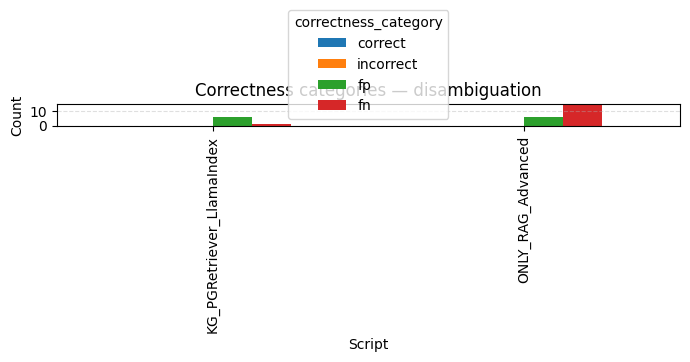

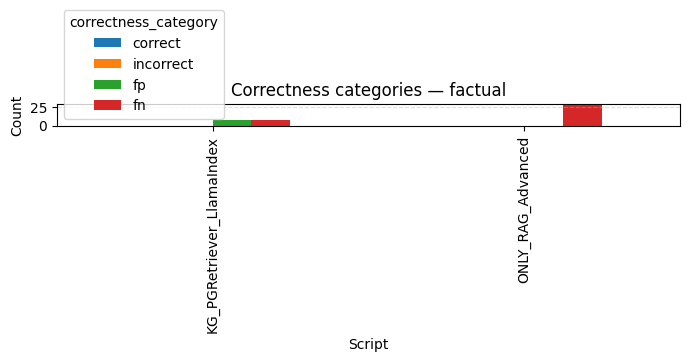

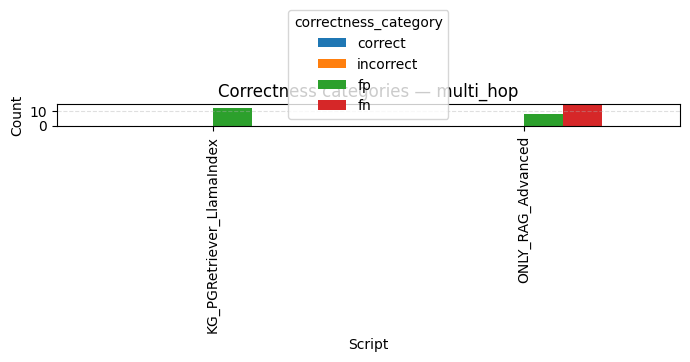

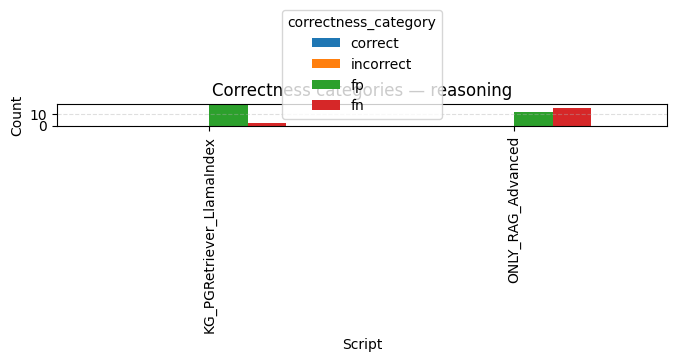

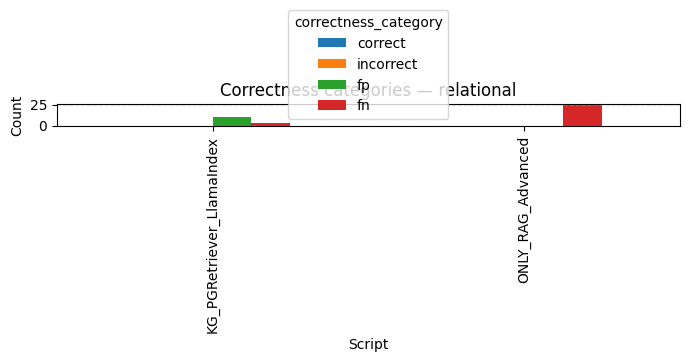

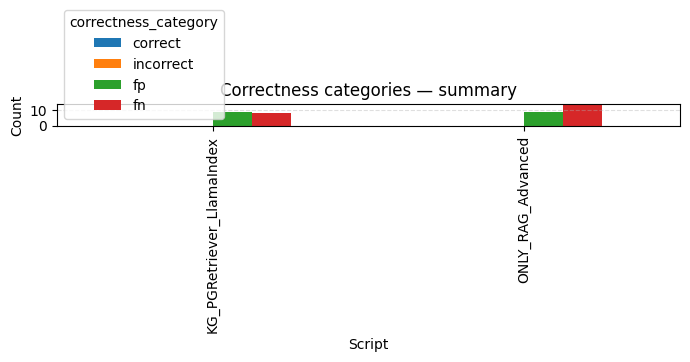

In [29]:
import matplotlib.pyplot as plt

def plot_correctness_counts(cat_table, categories=None):
    if categories is not None:
        for c in categories:
            if c not in cat_table.columns:
                cat_table[c] = 0
        cat_table = cat_table[categories]

    for qt in cat_table.index.get_level_values(0).unique():
        sub = cat_table.loc[qt]  # index=script

        fig, ax = plt.subplots(figsize=(7, 3))
        sub.plot(kind="bar", ax=ax)

        ax.set_title(f"Correctness categories — {qt}")
        ax.set_xlabel("Script")
        ax.set_ylabel("Count")
        ax.grid(axis="y", linestyle="--", alpha=0.4)

        plt.tight_layout()
        plt.show()

# Beispiel – passe Kategorien an deine echten Labels an!
plot_correctness_counts(
    cat_table,
    categories=["correct", "incorrect", "fp", "fn"]
)


In [31]:
import numpy as np
import matplotlib.pyplot as plt

def pretty_heatmap(pivot_df, title, vmin=None, vmax=None, cmap="Greys"):
    """
    Matplotlib-only heatmap with:
    - nice layout
    - cell annotations
    - readable labels
    """
    dfp = pivot_df.copy()

    # Ensure consistent order (optional): keep as-is, but you can sort:
    # dfp = dfp.sort_index()

    data = dfp.values.astype(float)

    # If vmin/vmax not provided, autoscale to data range for better contrast
    finite = np.isfinite(data)
    if vmin is None:
        vmin = np.nanmin(data[finite]) if finite.any() else 0.0
    if vmax is None:
        vmax = np.nanmax(data[finite]) if finite.any() else 1.0
    if vmin == vmax:
        vmax = vmin + 1e-6

    fig_w = max(6, 1.2 * dfp.shape[1] + 3)     # width depends on #scripts
    fig_h = max(3.5, 0.55 * dfp.shape[0] + 1)  # height depends on #query_types

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    im = ax.imshow(data, aspect="auto", vmin=vmin, vmax=vmax, cmap=cmap)

    # Title
    ax.set_title(title, pad=12)

    # Axis ticks
    ax.set_yticks(np.arange(dfp.shape[0]))
    ax.set_yticklabels(dfp.index)

    ax.set_xticks(np.arange(dfp.shape[1]))
    ax.set_xticklabels(dfp.columns, rotation=0, ha="center")

    # Grid lines for cell separation (subtle)
    ax.set_xticks(np.arange(-.5, dfp.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-.5, dfp.shape[0], 1), minor=True)
    ax.grid(which="minor", color="lightgray", linestyle="-", linewidth=0.6)
    ax.tick_params(which="minor", bottom=False, left=False)

    # Annotate cells with values
    for i in range(dfp.shape[0]):
        for j in range(dfp.shape[1]):
            val = data[i, j]
            if np.isfinite(val):
                # choose text color based on background brightness
                # (simple threshold on normalized value)
                norm = (val - vmin) / (vmax - vmin)
                text_color = "black" if norm < 0.65 else "white"
                ax.text(j, i, f"{val:.2f}", ha="center", va="center", color=text_color, fontsize=10)
            else:
                ax.text(j, i, "—", ha="center", va="center", color="black", fontsize=10)

    # Colorbar
    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.04)
    cbar.set_label("Mean score", rotation=90)

    plt.tight_layout()
    plt.show()


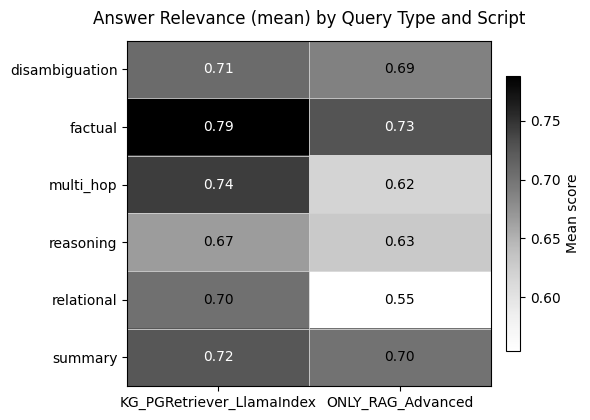

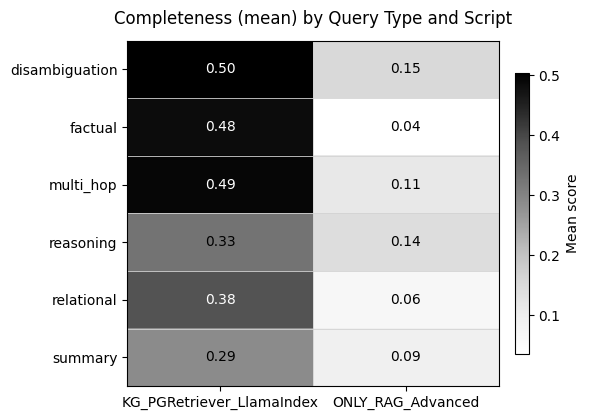

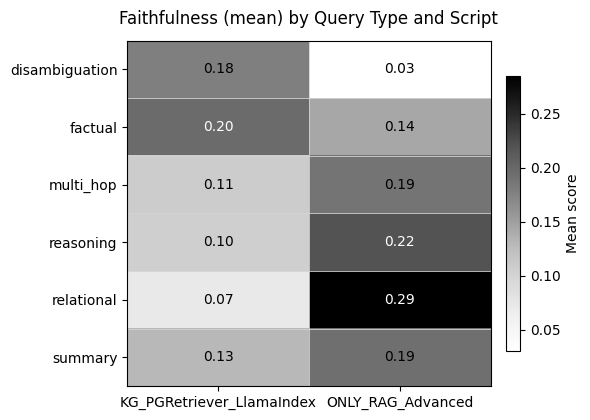

In [32]:
pretty_heatmap(rel_pivot,   "Answer Relevance (mean) by Query Type and Script")
pretty_heatmap(comp_pivot,  "Completeness (mean) by Query Type and Script")
pretty_heatmap(faith_pivot, "Faithfulness (mean) by Query Type and Script")


In [35]:
display(rel_pivot.round(2))
display(comp_pivot.round(2))
display(faith_pivot.round(2))



script,KG_PGRetriever_LlamaIndex,ONLY_RAG_Advanced
query_type,,
disambiguation,0.71,0.69
factual,0.79,0.73
multi_hop,0.74,0.62
reasoning,0.67,0.63
relational,0.70,0.55
summary,0.72,0.70


script,KG_PGRetriever_LlamaIndex,ONLY_RAG_Advanced
query_type,,
disambiguation,0.50,0.15
factual,0.48,0.04
multi_hop,0.49,0.11
reasoning,0.33,0.14
relational,0.38,0.06
summary,0.29,0.09


script,KG_PGRetriever_LlamaIndex,ONLY_RAG_Advanced
query_type,,
disambiguation,0.18,0.03
factual,0.20,0.14
multi_hop,0.11,0.19
reasoning,0.10,0.22
relational,0.07,0.29
summary,0.13,0.19


In [33]:
cat_counts = (
    df.groupby(["query_type", "script", "correctness_category"])
      .size()
      .rename("count")
      .reset_index()
)

cat_table = cat_counts.pivot_table(
    index=["query_type", "script"],
    columns="correctness_category",
    values="count",
    fill_value=0,
    aggfunc="sum"
).sort_index()

display(cat_table)


correctness_category                      fn  fp  tp
query_type     script                               
disambiguation KG_PGRetriever_LlamaIndex   1   6  15
               ONLY_RAG_Advanced          14   6   2
factual        KG_PGRetriever_LlamaIndex   7   7  15
               ONLY_RAG_Advanced          27   0   1
multi_hop      KG_PGRetriever_LlamaIndex   0  12  10
               ONLY_RAG_Advanced          14   8   0
reasoning      KG_PGRetriever_LlamaIndex   2  18   9
               ONLY_RAG_Advanced          16  12   1
relational     KG_PGRetriever_LlamaIndex   3  10  13
               ONLY_RAG_Advanced          24   0   2
summary        KG_PGRetriever_LlamaIndex   8   9   6
               ONLY_RAG_Advanced          13   9   1